# acai.pdf_to_json — Docling Adapter Demo

This notebook exercises the **DoclingParser** adapter (IBM Docling).

| Component | Name |
|-----------|------|
| **Port** | `PdfParserPort` (`parse_file`, `parse_bytes`) |
| **Domain** | `ParsedPdfDocument`, `PdfPage`, `PdfPageElement`, `PdfTextBlock`, `PdfImage`, `PdfTable` |
| **Adapter** | `DoclingParser` — IBM Docling |
| **Factory** | `create_pdf_parser(logger, use_docling=True)` |

Requires `pip install docling`. Docling uses deep-learning models for
layout analysis, table structure, and picture classification.

Sample PDFs are loaded from `_test/fixtures/` (shared between tests and examples).

In [3]:
PDF_FILE_NAME = "24030-03_06072004.pdf"

## 1 — Setup & Imports

In [4]:
from pathlib import Path
import json
import sys

# Ensure the local package root is importable in notebooks.
cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "lib" / "acai").exists()),
    None,
 )
if project_root is None:
    raise RuntimeError("Could not locate project root containing 'lib/acai'.")

lib_path = project_root / "lib"
if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

from acai.logging import LoggerConfig, LogLevel, create_logger
from acai.pdf_to_json import (
    ContentType,
    PdfParserConfig,
    create_pdf_parser,
 )

logger = create_logger(LoggerConfig(service_name="pdf-demo", log_level=LogLevel.INFO))

FIXTURES = (project_root / "lib" / "acai" / "pdf_to_json" / "_test" / "fixtures").resolve()
print(f"Project root: {project_root}")
print(f"Fixtures dir: {FIXTURES}")
print(f"Available PDFs: {[f.name for f in sorted(FIXTURES.glob('*.pdf'))]}")

Project root: D:\Repos Solutions\Public\acai-powertools
Fixtures dir: D:\Repos Solutions\Public\acai-powertools\lib\acai\pdf_to_json\_test\fixtures
Available PDFs: ['24006-15_06122016.pdf', '24030-03_06072004.pdf', '24071-03_05102004.pdf', 'basic-text.pdf', 'dev-example.pdf', 'sample-report.pdf', 'sample_multipage.pdf', 'sample_table.pdf', 'sample_text.pdf']


## 2 — Parse from file

In [5]:
docling_parser = create_pdf_parser(logger, use_docling=True)
print(f"Adapter: {type(docling_parser).__name__}")
print(f"Docling version: {docling_parser.VERSION}")

doc_dl = docling_parser.parse_file(FIXTURES / PDF_FILE_NAME)
print(f"Pages: {doc_dl.metadata.page_count}")
print()
for page in doc_dl.pages:
    print(f"--- Page {page.page_number} ---")
    for elem in page.elements:
        if elem.type == ContentType.TEXT:
            print(f"  [TEXT]  {elem.text_block.content[:80]}")
        elif elem.type == ContentType.TABLE:
            print(f"  [TABLE] {len(elem.table.rows)} rows")
        elif elem.type == ContentType.IMAGE:
            print(f"  [IMAGE] {elem.image.width}\u00d7{elem.image.height}")

2026-04-01 19:20:42,744 - INFO - Starting Docling PDF parsing from file | source_name=24030-03_06072004.pdf parser=docling extract_tables=True extract_images=True


Adapter: DoclingParser
Docling version: 0.1.0


d:\Repos Solutions\Public\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 11641.94it/s]
2026-04-01 19:22:08,687 - INFO - Docling page extraction completed | source_name=24030-03_06072004.pdf parser=docling page_count=10
2026-04-01 19:22:08,688 - INFO - Docling PDF parsing completed | source_name=24030-03_06072004.pdf parser=docling page_count=10


Pages: 10

--- Page 1 ---
  [TEXT]  BUNDESPATENTGERICHT
  [TEXT]  24 W (pat) 30/03
  [TEXT]  _______________
  [TEXT]  (Aktenzeichen)
  [TEXT]  …
  [TEXT]  BESCHLUSS
  [TEXT]  In der Beschwerdesache betreffend die Marke 399 00 552
  [TEXT]  Verkündet am 6. Juli 2004
  [TEXT]  …
  [TEXT]  BPatG 154 6.70
  [IMAGE] 281×83
--- Page 2 ---
  [TEXT]  - 2 -
  [TEXT]  hat  der  24. Senat  (Marken-Beschwerdesenat)  des  Bundespatentgerichts  auf  d
  [TEXT]  beschlossen:
  [TEXT]  Auf die Beschwerde der Widersprechenden wird der Beschluß der Markenstelle für K
  [TEXT]  Wegen des Widerspruchs aus der Marke 1 084 265 wird auch für die Waren "Schuhwar
  [TEXT]   Der  Antrag  auf  Rückzahlung  der  Beschwerdegebühr  wird  zurückgewiesen.
  [TEXT]  Gründe
  [TEXT]  I.
  [TEXT]  Die farbig ausgestaltete Marke
  [IMAGE] 170×88
--- Page 3 ---
  [TEXT]  - 3 -
  [TEXT]  ist unter der Nummer 399 00 552 u.a. für die Waren
  [TEXT]  "Bekleidungsstücke, Schuhwaren, Kopfbedeckungen"
  [TEXT]  in das Register 

## 3 — Extract and display images

Display image instances (adapter): 2
Image 1: page=1, size=281x83, format=png, bytes=13,141


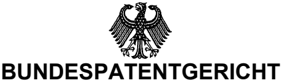

Image 2: page=2, size=170x88, format=png, bytes=27,289


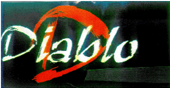

In [4]:
from IPython.display import Image, display

images = [
    (page.page_number, elem.image)
    for page in doc_dl.pages
    for elem in page.elements
    if elem.type == ContentType.IMAGE and elem.image and elem.image.data
]

print(f"Display image instances (adapter): {len(images)}")

max_to_show = 12
for idx, (page_no, img) in enumerate(images[:max_to_show], start=1):
    print(
        f"Image {idx}: page={page_no}, size={img.width}x{img.height}, "
        f"format={img.format}, bytes={len(img.data):,}"
    )
    display(Image(data=img.data, format=img.format.lower()))

if len(images) > max_to_show:
    print(f"... and {len(images) - max_to_show} more display image(s).")
elif not images:
    print("No display-worthy images were found in this sample PDF.")

## 4 — Parse from bytes

In [5]:
raw = (FIXTURES / PDF_FILE_NAME).read_bytes()
doc_dl_bytes = docling_parser.parse_bytes(raw, source_name=PDF_FILE_NAME)

print(f"Pages: {doc_dl_bytes.metadata.page_count}")
for page in doc_dl_bytes.pages:
    print(f"Page {page.page_number}: {len(page.elements)} elements")

Loading weights: 100%|██████████| 770/770 [00:00<00:00, 8610.72it/s]
2026-04-01 12:06:48,548 - INFO - Extracted 10 pages from '24030-03_06072004.pdf' via Docling


Pages: 10
Page 1: 11 elements
Page 2: 10 elements
Page 3: 10 elements
Page 4: 6 elements
Page 5: 5 elements
Page 6: 10 elements
Page 7: 4 elements
Page 8: 3 elements
Page 9: 6 elements
Page 10: 6 elements


## 5 — JSON serialisation (`to_dict`)

In [6]:
d = doc_dl.to_dict()

# Pretty-print the first page only (to keep output manageable)
first_page = {"metadata": d["metadata"], "pages": [d["pages"][0]]}
print(json.dumps(first_page, indent=2, ensure_ascii=False))

{
  "metadata": {
    "title": null,
    "author": null,
    "subject": null,
    "creator": null,
    "producer": null,
    "page_count": 10
  },
  "pages": [
    {
      "page_number": 1,
      "width": 0.0,
      "height": 0.0,
      "elements": [
        {
          "type": "text",
          "text_block": {
            "content": "BUNDESPATENTGERICHT",
            "font_name": null,
            "font_size": null
          }
        },
        {
          "type": "text",
          "text_block": {
            "content": "24 W (pat) 30/03",
            "font_name": null,
            "font_size": null
          }
        },
        {
          "type": "text",
          "text_block": {
            "content": "_______________",
            "font_name": null,
            "font_size": null
          }
        },
        {
          "type": "text",
          "text_block": {
            "content": "(Aktenzeichen)",
            "font_name": null,
            "font_size": null
          }
    